Используя базу "Аудиожанры", примените подход к музыке как к тексту и напишите сверточный классификатор (на базе слоя Conv1D) для подготовленных данных. Для этого:

1. Измените подготовку данных так, чтобы набор признаков, извлекаемый из аудиофайла, был представлен в виде последовательностей векторов признаков. Последовательности должны быть фиксированного размера и выбираться скользящим окном c заданным шагом. Другими словами: берем аудио-файл длительность, например, 30 сек. Берем отрезок фиксированной длины (например, 5с) и получаем набор признаков для этого отрезка. Смещаемся на шаг (например, 1с) и берем следующий отрезок. Таким образом готовим обучающую вборку.
2. Длину последовательности, размер шага и достаточный набор признаков определите самостоятельно исходя из требований к точности классификатора;
3. Разработайте классификатор на одномерных сверточных слоях **Conv1D** с точностью классификации жанра на тестовых данных не ниже **60%**, а на обучающих файлах - **68%** и выше;
4. Используйте за основу материал с урока, но при желании разработайте свои инструменты.

In [1]:
import os
import time
import warnings

import gdown
import librosa
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Flatten,
    Conv1D,
    MaxPooling1D,
    SpatialDropout1D
)

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline


Библиотеки загружены


In [2]:
gdown.download(
    'https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip',
    None,
    quiet=True
)

!unzip -qo genres.zip

print('Жанры в датасете:')
!ls genres

Жанры в датасете:
blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock


In [3]:
DATA_DIR = './genres'

# Сортировка списков жанров
GENRE_NAMES = sorted(os.listdir(DATA_DIR))
GENRE_COUNT = len(GENRE_NAMES)

# Длина считываемого фрагмента трека
TRACK_SECONDS = 30

# Все треки приводятся к одинаковому числу временных кадров
FRAME_LIMIT = 1200

# Параметры скользящего окна
SEQ_SIZE = 150
SEQ_STEP = 50


def read_audio_features(audio_file, seconds=TRACK_SECONDS):

    # Загружаем аудио в моно-режиме
    signal, sample_rate = librosa.load(audio_file, mono=True, duration=seconds)

    # Общие параметры для спектральных признаков
    fft_size = 2048
    hop = 512

    # Извлекаем признаки по временным фреймам
    chroma = librosa.feature.chroma_stft(
        y=signal, sr=sample_rate, n_fft=fft_size, hop_length=hop
    )
    mfcc = librosa.feature.mfcc(
        y=signal, sr=sample_rate, n_fft=fft_size, hop_length=hop, n_mfcc=20
    )
    rms = librosa.feature.rms(y=signal, hop_length=hop)
    centroid = librosa.feature.spectral_centroid(
        y=signal, sr=sample_rate, n_fft=fft_size, hop_length=hop
    )
    bandwidth = librosa.feature.spectral_bandwidth(
        y=signal, sr=sample_rate, n_fft=fft_size, hop_length=hop
    )
    rolloff = librosa.feature.spectral_rolloff(
        y=signal, sr=sample_rate, n_fft=fft_size, hop_length=hop
    )
    zero_crossings = librosa.feature.zero_crossing_rate(signal, hop_length=hop)

    # Собираем признаки в таблицу
    feature_table = np.vstack([
        chroma,
        mfcc,
        rms,
        centroid,
        bandwidth,
        rolloff,
        zero_crossings
    ]).T.astype('float32')

    # Выравниваем длину матрицы признаков для всех треков
    current_frames = feature_table.shape[0]
    if current_frames < FRAME_LIMIT:
        missing_frames = FRAME_LIMIT - current_frames
        feature_table = np.pad(
            feature_table,
            ((0, missing_frames), (0, 0)),
            mode='constant'
        )
    else:
        feature_table = feature_table[:FRAME_LIMIT]

    return feature_table


def make_windows(feature_table, seq_size=SEQ_SIZE, seq_step=SEQ_STEP):

    windows = []
    last_start = feature_table.shape[0] - seq_size + 1

    for left in range(0, last_start, seq_step):
        right = left + seq_size
        windows.append(feature_table[left:right])

    return np.array(windows, dtype='float32')

In [4]:
def load_track_tables(data_dir, genres, train_border=90):

    train_tables, train_labels = [], []
    test_tables, test_labels = [], []

    for genre_id, genre_name in enumerate(genres):
        genre_path = os.path.join(data_dir, genre_name)
        track_names = sorted(os.listdir(genre_path))

        for track_id, track_name in enumerate(track_names):
            track_path = os.path.join(genre_path, track_name)

            try:
                feature_table = read_audio_features(track_path)
            except Exception:
                continue

            # Первые 90 файлов жанра идут в обучение остальные в тест
            if track_id < train_border:
                train_tables.append(feature_table)
                train_labels.append(genre_id)
            else:
                test_tables.append(feature_table)
                test_labels.append(genre_id)

    return train_tables, train_labels, test_tables, test_labels


def normalize_feature_tables(train_tables, test_tables):

    all_train_rows = np.concatenate(train_tables, axis=0)

    scaler = StandardScaler()
    scaler.fit(all_train_rows)

    train_scaled = [scaler.transform(table).astype('float32') for table in train_tables]
    test_scaled = [scaler.transform(table).astype('float32') for table in test_tables]

    return train_scaled, test_scaled, scaler


def build_window_dataset(track_tables, track_labels):

    x_parts = []
    y_parts = []

    for table, label in zip(track_tables, track_labels):
        track_windows = make_windows(table)
        x_parts.append(track_windows)
        y_parts.append(np.full(len(track_windows), label))

    x_data = np.concatenate(x_parts, axis=0)
    y_data = np.concatenate(y_parts, axis=0)

    return x_data, y_data


print('Начинается извлечение признаков из аудиофайлов')
start = time.time()

raw_train, train_labels, raw_test, test_labels = load_track_tables(DATA_DIR, GENRE_NAMES)

print(f'Извлечение признаков завершено за {round(time.time() - start)} сек.')

# Нормируем признаки после чтения всех обучающих треков
train_scaled, test_scaled, audio_scaler = normalize_feature_tables(raw_train, raw_test)

# Нарезаем каждый трек на последовательности признаков
X_train, y_train = build_window_dataset(train_scaled, train_labels)
X_test, y_test = build_window_dataset(test_scaled, test_labels)

# Метки переводятся в формат для категорий
y_train_cat = to_categorical(y_train, num_classes=GENRE_COUNT)
y_test_cat = to_categorical(y_test, num_classes=GENRE_COUNT)

print('\nРазмеры данных для обучения Conv1D:')
print(f'X_train: {X_train.shape}, y_train_cat: {y_train_cat.shape}')
print(f'X_test:  {X_test.shape}, y_test_cat:  {y_test_cat.shape}')

Начинается извлечение признаков из аудиофайлов
Извлечение признаков завершено за 335 сек.

Размеры данных для обучения Conv1D:
X_train: (19800, 150, 37), y_train_cat: (19800, 10)
X_test:  (2200, 150, 37), y_test_cat:  (2200, 10)


In [5]:
def build_conv_classifier(input_shape, class_count):

    model = Sequential(name='audio_genre_conv1d')

    model.add(Input(shape=input_shape))

    # Первый блок выделяет простые локальные закономерности
    model.add(Conv1D(64, kernel_size=5, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(SpatialDropout1D(0.2))

    # Второй блок повышает количество фильтров
    model.add(Conv1D(128, kernel_size=3, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(SpatialDropout1D(0.2))

    # Третий блок извлекает более сложные сочетания признаков
    model.add(Conv1D(256, kernel_size=3, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(SpatialDropout1D(0.3))

    # Переход к вектору
    model.add(Flatten())

    # Полносвязная часть выполняет итоговую классификацию
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(class_count, activation='softmax'))

    return model


# Форма входа берётся прямо из обучающей выборки
input_shape = (X_train.shape[1], X_train.shape[2])

conv_model = build_conv_classifier(input_shape, GENRE_COUNT)

# Компилируем модель для многоклассовой классификации
conv_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

conv_model.summary()

Model: "audio_genre_conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 150, 64)        │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 75, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 75, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 37, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 18, 256)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,458 (5.04 MB)

 Trainable params: 1,319,050 (5.03 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [6]:
print('Запуск обучения сверточной модели')

# Обучаем модель на окнах аудиопризнаков
history_conv = conv_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    batch_size=64,
    epochs=40,
    verbose=1
)

Запуск обучения сверточной модели
Epoch 1/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.5078 - loss: 1.5220 - val_accuracy: 0.5059 - val_loss: 1.6578
Epoch 2/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6504 - loss: 1.0047 - val_accuracy: 0.5609 - val_loss: 1.4069
Epoch 3/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7030 - loss: 0.8425 - val_accuracy: 0.6409 - val_loss: 1.2274
Epoch 4/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7422 - loss: 0.7281 - val_accuracy: 0.6273 - val_loss: 1.2645
Epoch 5/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7746 - loss: 0.6477 - val_accuracy: 0.6536 - val_loss: 1.2446
Epoch 6/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7927 - loss: 0.5859 - val_accuracy: 0.6205 - val_loss: 1.3325
Epoch 7/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8136 - loss: 0.5326 - val_accuracy: 0.6468 - val_loss: 1.2975
Epoch 8/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.83

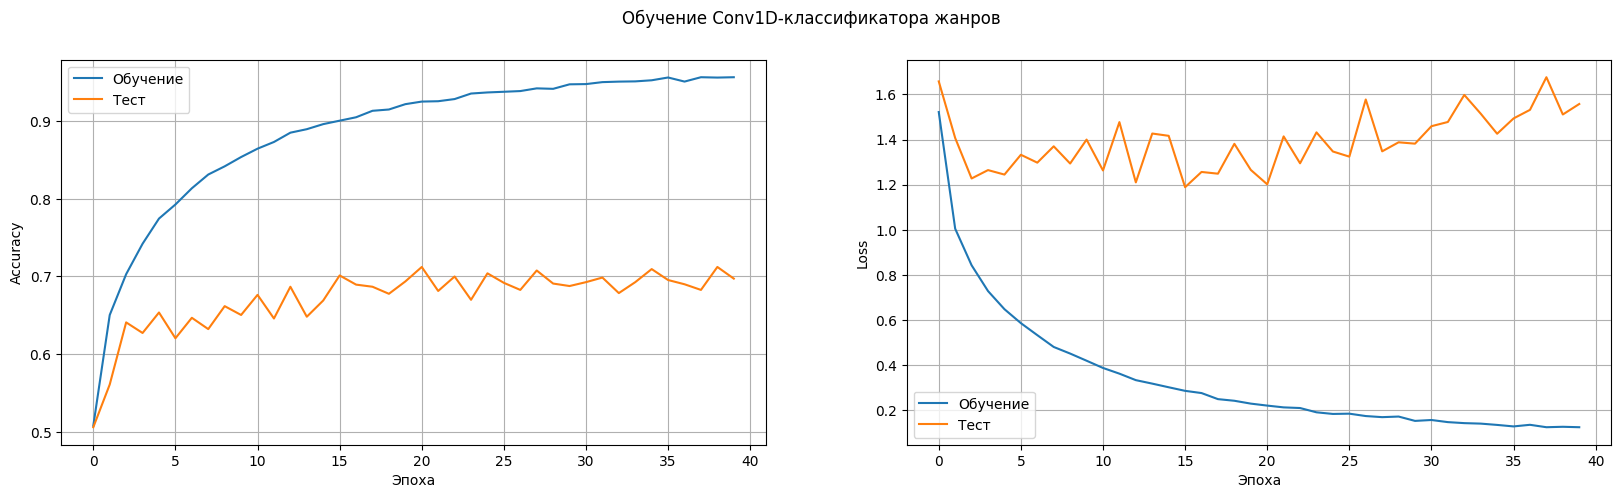


Точность на обучающих данных: 99.81%  Требуется: >= 68%
Точность на тестовых данных:  69.73%  Требуется: >= 60%
Требования задания выполнены


In [7]:
def show_training_result(history):

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle('Обучение Conv1D-классификатора жанров')

    # График точности
    axes[0].plot(history.history['accuracy'], label='Обучение')
    axes[0].plot(history.history['val_accuracy'], label='Тест')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # График функции ошибки
    axes[1].plot(history.history['loss'], label='Обучение')
    axes[1].plot(history.history['val_loss'], label='Тест')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.show()


def print_final_quality(model):

    train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

    print('\n' + '=' * 50)
    print(f'Точность на обучающих данных: {round(train_acc * 100, 2)}%  Требуется: >= 68%')
    print(f'Точность на тестовых данных:  {round(test_acc * 100, 2)}%  Требуется: >= 60%')
    print('=' * 50)

    if train_acc >= 0.68 and test_acc >= 0.60:
        print('Требования задания выполнены')
    else:
        print('Требуемая точность не достигнута')


show_training_result(history_conv)
print_final_quality(conv_model)